# TRANSFORMACIÓN DE DATOS

## IMPORTAR PAQUETES

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [201]:
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_eda.pkl')
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_eda.pkl')

Recordamos lo que habíamos identificado en fases anteriores y lo organizamos por tipo de acción.

Modificar con pandas/numpy:

* Crear la target a partir de estado
* Discretizar num_meses_desde_ult_retraso
* En vivienda juntar ANY, NONE y OTHER
* En finalidad juntar renewable_energy, educational y wedding en 'otros'

Modificar con scikit learn:

* Convertir num_derogatorios a binaria

## CREACIÓN DE VARIABLES Y TRANSFORMACIONES CON PANDAS

### Target para el modelo PD

Crear la target a partir de estado

In [202]:
cat.estado.value_counts()

estado
Fully Paid                                             66411
Current                                                54278
Charged Off                                            16583
Late (31-120 days)                                      1349
In Grace Period                                          518
Late (16-30 days)                                        286
Does not meet the credit policy. Status:Fully Paid       113
Does not meet the credit policy. Status:Charged Off       57
Default                                                    2
Name: count, dtype: int64

In [203]:
cat['target_pd'] = np.where(cat.estado.isin(['Charged Off','Does not meet the credit policy. Status:Charged Off','Default']), 1, 0)
cat

,antigüedad_empleo,ingresos_verificados,rating,vivienda,finalidad,num_cuotas,estado,target_pd
0,3 years,Source Verified,A,MORTGAGE,debt_consolidation,36 months,Current,0
1,10+ years,Not Verified,D,RENT,debt_consolidation,36 months,Charged Off,1
2,5 years,Verified,A,RENT,debt_consolidation,36 months,Fully Paid,0
3,9 years,Source Verified,B,MORTGAGE,credit_card,60 months,Current,0
4,10+ years,Source Verified,D,MORTGAGE,home_improvement,60 months,Current,0
...,...,...,...,...,...,...,...,...
139995,desconocido,Source Verified,C,RENT,debt_consolidation,36 months,Late (31-120 days),0
139996,10+ years,Not Verified,C,MORTGAGE,debt_consolidation,36 months,Fully Paid,0
139997,10+ years,Source Verified,D,MORTGAGE,small_business,36 months,Current,0
139998,8 years,Source Verified,E,RENT,small_business,60 months,Charged Off,1


In [204]:
cat.drop(columns='estado',inplace=True)

### Target para el modelo EAD

Será el porcentaje del principal que no había sido amortizado.

Por tanto: pendiente / principal

Primero tenemos que construir el pendiente como el principal menos el amortizado.

In [205]:
num['pendiente'] = num.principal - num.imp_amortizado
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente
0,137387967,54000.000,19.310,2,10,33.300,45.200,0,0,10,15000.000,7.210,464.600,2669.060,0.000,19.310,12330.940
1,4798121,65000.000,25.400,1,15,85.700,86.200,0,0,0,10000.000,17.770,360.380,6362.960,0.000,25.400,3637.040
2,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000
3,87998444,188000.000,11.690,3,15,0.000,3.300,0,0,0,27000.000,8.990,560.350,12443.000,0.000,11.690,14557.000
4,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,119242742,20000.000,8.020,0,5,66.700,33.200,0,0,0,2500.000,12.620,83.780,996.060,0.000,8.020,1503.940
139996,51876926,42000.000,20.850,6,9,100.000,81.600,0,0,13,8000.000,12.290,266.830,8000.000,0.000,20.850,0.000
139997,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470
139998,53664762,168000.000,4.690,0,8,0.000,52.400,0,2,0,30050.000,18.250,767.170,2964.440,2750.880,4.690,27085.560


In [206]:
num['target_ead'] = num.pendiente / num.principal
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead
0,137387967,54000.000,19.310,2,10,33.300,45.200,0,0,10,15000.000,7.210,464.600,2669.060,0.000,19.310,12330.940,0.822
1,4798121,65000.000,25.400,1,15,85.700,86.200,0,0,0,10000.000,17.770,360.380,6362.960,0.000,25.400,3637.040,0.364
2,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000
3,87998444,188000.000,11.690,3,15,0.000,3.300,0,0,0,27000.000,8.990,560.350,12443.000,0.000,11.690,14557.000,0.539
4,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,119242742,20000.000,8.020,0,5,66.700,33.200,0,0,0,2500.000,12.620,83.780,996.060,0.000,8.020,1503.940,0.602
139996,51876926,42000.000,20.850,6,9,100.000,81.600,0,0,13,8000.000,12.290,266.830,8000.000,0.000,20.850,0.000,0.000
139997,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820
139998,53664762,168000.000,4.690,0,8,0.000,52.400,0,2,0,30050.000,18.250,767.170,2964.440,2750.880,4.690,27085.560,0.901


### Target para el modelo LGD

Será el porcentaje del pendiente que NO se recupera en caso de impago.

Por tanto: 1 - (imp_recuperado / pendiente)

In [207]:
num['target_lgd'] = 1 - (num.imp_recuperado / num.pendiente)
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead,target_lgd
0,137387967,54000.000,19.310,2,10,33.300,45.200,0,0,10,15000.000,7.210,464.600,2669.060,0.000,19.310,12330.940,0.822,1.000
1,4798121,65000.000,25.400,1,15,85.700,86.200,0,0,0,10000.000,17.770,360.380,6362.960,0.000,25.400,3637.040,0.364,1.000
2,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000,NaN
3,87998444,188000.000,11.690,3,15,0.000,3.300,0,0,0,27000.000,8.990,560.350,12443.000,0.000,11.690,14557.000,0.539,1.000
4,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,119242742,20000.000,8.020,0,5,66.700,33.200,0,0,0,2500.000,12.620,83.780,996.060,0.000,8.020,1503.940,0.602,1.000
139996,51876926,42000.000,20.850,6,9,100.000,81.600,0,0,13,8000.000,12.290,266.830,8000.000,0.000,20.850,0.000,0.000,NaN
139997,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820,1.000
139998,53664762,168000.000,4.690,0,8,0.000,52.400,0,2,0,30050.000,18.250,767.170,2964.440,2750.880,4.690,27085.560,0.901,0.898


Los nulos se producen cuando el pendiente es cero. Por tanto podemos imputarlos por ceros.

In [208]:
num['target_lgd'] = num['target_lgd'].fillna(0)
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead,target_lgd
0,137387967,54000.000,19.310,2,10,33.300,45.200,0,0,10,15000.000,7.210,464.600,2669.060,0.000,19.310,12330.940,0.822,1.000
1,4798121,65000.000,25.400,1,15,85.700,86.200,0,0,0,10000.000,17.770,360.380,6362.960,0.000,25.400,3637.040,0.364,1.000
2,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000,0.000
3,87998444,188000.000,11.690,3,15,0.000,3.300,0,0,0,27000.000,8.990,560.350,12443.000,0.000,11.690,14557.000,0.539,1.000
4,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,119242742,20000.000,8.020,0,5,66.700,33.200,0,0,0,2500.000,12.620,83.780,996.060,0.000,8.020,1503.940,0.602,1.000
139996,51876926,42000.000,20.850,6,9,100.000,81.600,0,0,13,8000.000,12.290,266.830,8000.000,0.000,20.850,0.000,0.000,0.000
139997,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820,1.000
139998,53664762,168000.000,4.690,0,8,0.000,52.400,0,2,0,30050.000,18.250,767.170,2964.440,2750.880,4.690,27085.560,0.901,0.898


Comprobamos las targets creadas.

In [209]:
cat[['target_pd']].describe().T

,count,mean,std,min,25%,50%,75%,max
target_pd,139597.000,0.119,0.324,0.000,0.000,0.000,0.000,1.000


In [210]:
num[['target_ead','target_lgd']].describe().T

,count,mean,std,min,25%,50%,75%,max
target_ead,139597.000,0.338,0.369,-0.000,0.000,0.129,0.725,1.000
target_lgd,139597.000,0.509,0.490,-0.248,0.000,0.851,1.000,1.000


Limitamos para garantizar que siempre estén entre 0 y 1

In [211]:
num.target_ead = np.where(num.target_ead < 0, 0, num.target_ead)
num.target_ead = np.where(num.target_ead > 1, 1, num.target_ead)
num.target_lgd = np.where(num.target_lgd < 0, 0, num.target_lgd)
num.target_lgd = np.where(num.target_lgd > 1, 1, num.target_lgd)

In [212]:
num[['target_ead','target_lgd']].describe().T

,count,mean,std,min,25%,50%,75%,max
target_ead,139597.000,0.338,0.369,0.000,0.000,0.129,0.725,1.000
target_lgd,139597.000,0.509,0.490,0.000,0.000,0.851,1.000,1.000


### Resto de variables

num_meses_desde_ult_retraso

Vamos a comenzar revisando la relación con la target_pd

In [213]:
temp = num[['num_meses_desde_ult_retraso']].copy()

In [214]:
temp['num_meses_desde_ult_retraso_tramos'] = pd.cut(temp['num_meses_desde_ult_retraso'],20)
temp['target'] = cat['target_pd']

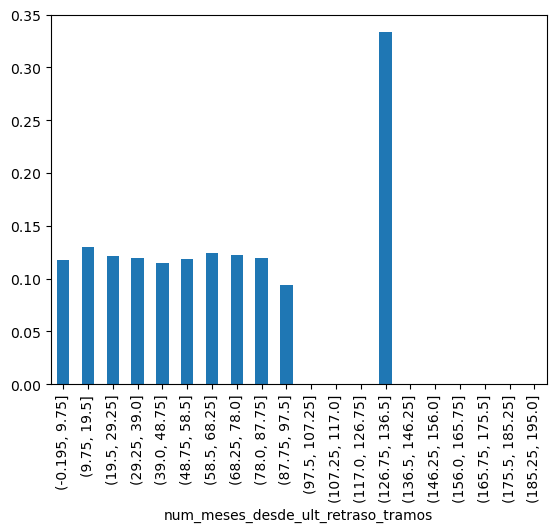

In [215]:
temp.groupby('num_meses_desde_ult_retraso_tramos', observed=False).target.mean().plot.bar();

La distribución de la target en esta variable no nos genera confianza, así que la descartamos.

In [216]:
num.drop(columns='num_meses_desde_ult_retraso',inplace=True)

En vivienda juntar ANY, NONE y OTHER

In [217]:
cat.vivienda.value_counts()

vivienda
MORTGAGE    68510
RENT        55634
OWN         15386
ANY            54
OTHER          11
NONE            2
Name: count, dtype: int64

In [218]:
cat.vivienda = cat.vivienda.replace(['ANY','NONE','OTHER'],'MORTGAGE')

In [219]:
cat.vivienda.value_counts()

vivienda
MORTGAGE    68577
RENT        55634
OWN         15386
Name: count, dtype: int64

En finalidad juntar renewable_energy, educational y wedding en 'otros'

In [220]:
cat.finalidad.value_counts()

finalidad
debt_consolidation    79281
credit_card           31584
home_improvement       9083
other                  8675
major_purchase         3157
medical                1697
small_business         1579
car                    1433
moving                  992
vacation                989
house                   890
wedding                 129
renewable_energy         84
educational              24
Name: count, dtype: int64

In [221]:
cat.finalidad = cat.finalidad.replace(['wedding','educational','renewable_energy'],'other')

In [222]:
cat.finalidad.value_counts()

finalidad
debt_consolidation    79281
credit_card           31584
home_improvement       9083
other                  8912
major_purchase         3157
medical                1697
small_business         1579
car                    1433
moving                  992
vacation                989
house                   890
Name: count, dtype: int64

## TRANSFORMACIÓN DE CATEGÓRICAS

### One Hot Encoding

#### Variables a aplicar OHE

In [223]:
var_ohe = [ 'ingresos_verificados', 'vivienda','finalidad','num_cuotas']

#### Instanciar

In [224]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, handle_unknown='ignore')

#### Entrenar y aplicar

In [225]:
cat_ohe = ohe.fit_transform(cat[var_ohe])

#### Guardar como dataframe

In [226]:
cat_ohe = pd.DataFrame(cat_ohe, columns = ohe.get_feature_names_out())
cat_ohe.head()

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,finalidad_house,finalidad_major_purchase,finalidad_medical,finalidad_moving,finalidad_other,finalidad_small_business,finalidad_vacation,num_cuotas_ 36 months,num_cuotas_ 60 months
0,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
2,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
3,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
4,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000


### Ordinal Encoding

#### Variables a aplicar OE

In [227]:
var_oe = ['antigüedad_empleo','rating']

#### Orden de los valores de las variables

In [228]:
#Orden de la primera variable
orden_antigüedad_empleo = ['desconocido','< 1 year','1 year','2 years','3 years','4 years',
                           '5 years','6 years','7 years','8 years','9 years','10+ years']

#Orden de la segunda variable
orden_rating = ['A','B','C','D','E','F','G']

#### Instanciar

In [229]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories = [orden_antigüedad_empleo,orden_rating],
                    handle_unknown = 'use_encoded_value',
                    unknown_value = 12)

#### Entrenar y aplicar

In [230]:
cat_oe = oe.fit_transform(cat[var_oe])

#### Guardar como dataframe

In [231]:
#Añadir sufijos a los nombres
nombres_oe = [variable + '_oe' for variable in var_oe]

#Guardar como dataframe
cat_oe = pd.DataFrame(cat_oe, columns = nombres_oe)
cat_oe.head()

,antigüedad_empleo_oe,rating_oe
0,4.000,0.000
1,11.000,3.000
2,6.000,0.000
3,10.000,1.000
4,11.000,3.000


## TRANSFORMACIÓN DE NUMÉRICAS

### Binarizar variables

#### Variables a binarizar

In [232]:
var_bin = ['num_derogatorios']

#### Instanciar

In [233]:
from sklearn.preprocessing import Binarizer
bin = Binarizer(threshold=0)

#### Entrenar y aplicar

In [234]:
num_bin = bin.fit_transform(num[var_bin])

#### Guardar como dataframe

In [235]:
#Añadir sufijos a los nombres
nombres_bin = [variable + '_bin' for variable in var_bin]

#Guardar como dataframe
num_bin = pd.DataFrame(num_bin,columns = nombres_bin)
num_bin.value_counts()

num_derogatorios_bin
0                       117601
1                        21996
Name: count, dtype: int64

## REESCALAR VARIABLES

### Con Min-Max

Unificar los datasets a reescalar.

In [236]:
num_escalar = num[['ingresos',
                  'dti',
                  'num_lineas_credito',
                  'porc_uso_revolving',
                  'principal',
                  'tipo_interes',
                  'imp_cuota']].reset_index(drop=True)

In [237]:
df_res = pd.concat([cat_oe,num_escalar], axis=1)

In [238]:
df_res

,antigüedad_empleo_oe,rating_oe,ingresos,dti,num_lineas_credito,porc_uso_revolving,principal,tipo_interes,imp_cuota
0,4.000,0.000,54000.000,19.310,10,45.200,15000.000,7.210,464.600
1,11.000,3.000,65000.000,25.400,15,86.200,10000.000,17.770,360.380
2,6.000,0.000,135000.000,14.680,19,16.300,24000.000,6.390,734.380
3,10.000,1.000,188000.000,11.690,15,3.300,27000.000,8.990,560.350
4,11.000,3.000,72777.000,24.740,10,63.200,25000.000,21.850,688.350
...,...,...,...,...,...,...,...,...,...
139592,0.000,2.000,20000.000,8.020,5,33.200,2500.000,12.620,83.780
139593,11.000,2.000,42000.000,20.850,9,81.600,8000.000,12.290,266.830
139594,11.000,3.000,285000.000,6.020,9,21.100,30000.000,17.470,1076.620
139595,9.000,4.000,168000.000,4.690,8,52.400,30050.000,18.250,767.170


#### Variables a reescalar con Min-Max

In [239]:
var_mms = df_res.columns

#### Instanciar

In [240]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

#### Entrenar y aplicar

In [241]:
df_mms = mms.fit_transform(df_res[var_mms])

#### Guardar como dataframe

In [242]:
#Añadir sufijos a los nombres
nombres_mms = [variable + '_mms' for variable in var_mms]

#Guardar como dataframe
df_mms = pd.DataFrame(df_mms,columns = nombres_mms)
df_mms.describe().T

,count,mean,std,min,25%,50%,75%,max
antigüedad_empleo_oe_mms,139597.000,0.589,0.361,0.000,0.273,0.545,1.000,1.000
rating_oe_mms,139597.000,0.277,0.210,0.000,0.167,0.333,0.333,1.000
ingresos_mms,139597.000,0.190,0.114,0.000,0.115,0.163,0.231,1.000
dti_mms,139597.000,0.020,0.015,0.000,0.013,0.019,0.025,1.000
num_lineas_credito_mms,139597.000,0.128,0.062,0.000,0.088,0.121,0.154,1.000
porc_uso_revolving_mms,139597.000,0.504,0.247,0.000,0.317,0.504,0.694,1.000
principal_mms,139597.000,0.359,0.235,0.000,0.179,0.303,0.487,1.000
tipo_interes_mms,139597.000,0.303,0.188,0.000,0.163,0.285,0.416,1.000
imp_cuota_mms,139597.000,0.256,0.156,0.000,0.143,0.217,0.342,1.000


## UNIFICAR DATASETS

### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de PD

In [243]:
incluir_pd = [num[['id_cliente']].reset_index(drop=True), cat_ohe, df_mms, num_bin, cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de PD

In [244]:
df_pd = pd.concat(incluir_pd, axis = 1)

In [245]:
df_pd

,id_cliente,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_pd
0,137387967,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,...,0.000,0.135,0.020,0.110,0.452,0.359,0.074,0.268,0,0
1,4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.500,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,1
2,46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.000,0.338,0.016,0.209,0.163,0.590,0.042,0.426,0,0
3,87998444,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,...,0.167,0.470,0.013,0.165,0.033,0.667,0.143,0.324,0,0
4,131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.182,0.026,0.110,0.632,0.615,0.644,0.399,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139592,119242742,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.333,0.050,0.009,0.055,0.332,0.038,0.285,0.045,0,0
139593,51876926,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,...,0.333,0.105,0.022,0.099,0.816,0.179,0.272,0.152,0,0
139594,135641397,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.713,0.007,0.099,0.211,0.744,0.474,0.626,0,0
139595,53664762,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,...,0.667,0.420,0.006,0.088,0.524,0.745,0.504,0.445,1,1


In [246]:
df_pd.set_index('id_cliente',inplace=True)
df_pd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
137387967,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.000,0.135,0.020,0.110,0.452,0.359,0.074,0.268,0,0
4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,1
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.000,0.338,0.016,0.209,0.163,0.590,0.042,0.426,0,0
87998444,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.167,0.470,0.013,0.165,0.033,0.667,0.143,0.324,0,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.500,0.182,0.026,0.110,0.632,0.615,0.644,0.399,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119242742,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.333,0.050,0.009,0.055,0.332,0.038,0.285,0.045,0,0
51876926,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.333,0.105,0.022,0.099,0.816,0.179,0.272,0.152,0,0
135641397,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.713,0.007,0.099,0.211,0.744,0.474,0.626,0,0


### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de EAD

Notar que necesitamos incluir también target_pd porque para modelizar ead debemos hacerlo solo sobre los defaults.

A diferencia del PD en los modelos EAD y LGD solo se usan los defaults para modelizar.

El motivo es que LGD y EAD modelan la severidad del default una vez ocurre. Si el default no ocurre, no hay severidad que observar.

In [247]:
incluir_ead = [cat_ohe, df_mms, num_bin, num.reset_index()[['id_cliente','target_ead']], cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de EAD

In [248]:
df_ead = pd.concat(incluir_ead, axis = 1)

In [249]:
df_ead.set_index('id_cliente',inplace=True)
df_ead

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_ead,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
137387967,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.135,0.020,0.110,0.452,0.359,0.074,0.268,0,0.822,0
4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,0.364,1
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.338,0.016,0.209,0.163,0.590,0.042,0.426,0,0.000,0
87998444,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.470,0.013,0.165,0.033,0.667,0.143,0.324,0,0.539,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.182,0.026,0.110,0.632,0.615,0.644,0.399,0,0.888,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119242742,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.050,0.009,0.055,0.332,0.038,0.285,0.045,0,0.602,0
51876926,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.105,0.022,0.099,0.816,0.179,0.272,0.152,0,0.000,0
135641397,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.713,0.007,0.099,0.211,0.744,0.474,0.626,0,0.820,0


In [250]:
# filtrar solo los clientes que incumplieron y eliminar la variable target_pd
df_ead = df_ead[df_ead.target_pd == 1].drop(columns='target_pd')
df_ead

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_ead
id_cliente,,,,,,,,,,,,,,,,,,,,,
4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,0.364
77861711,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.333,0.125,0.030,0.088,0.408,0.344,0.389,0.289,0,0.840
88146689,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.095,0.009,0.231,0.555,0.179,0.533,0.167,0,0.570
98927973,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.500,0.150,0.014,0.121,0.099,0.590,0.494,0.504,1,0.647
66456046,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.100,0.012,0.209,0.712,0.231,0.230,0.188,0,0.729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94254124,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.333,0.275,0.020,0.154,0.542,0.615,0.416,0.352,0,0.883
8156906,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.081,0.021,0.099,0.829,0.144,0.299,0.126,1,0.630
74603777,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.167,0.205,0.023,0.264,0.523,0.538,0.212,0.416,0,0.198


### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de LGD

Notar que necesitamos incluir también target_pd porque para modelizar lgd debemos hacerlo solo sobre los defaults.

In [251]:
incluir_lgd = [cat_ohe, df_mms, num_bin, num.reset_index()[['id_cliente','target_lgd']], cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de LGD

In [252]:
df_lgd = pd.concat(incluir_lgd, axis = 1)

In [253]:
df_lgd.set_index('id_cliente',inplace=True)
df_lgd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_lgd,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
137387967,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.135,0.020,0.110,0.452,0.359,0.074,0.268,0,1.000,0
4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,1.000,1
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.338,0.016,0.209,0.163,0.590,0.042,0.426,0,0.000,0
87998444,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.470,0.013,0.165,0.033,0.667,0.143,0.324,0,1.000,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.182,0.026,0.110,0.632,0.615,0.644,0.399,0,1.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119242742,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.050,0.009,0.055,0.332,0.038,0.285,0.045,0,1.000,0
51876926,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.105,0.022,0.099,0.816,0.179,0.272,0.152,0,0.000,0
135641397,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.713,0.007,0.099,0.211,0.744,0.474,0.626,0,1.000,0


In [254]:
# filtrar solo los clientes que incumplieron y eliminar la variable target_pd
df_lgd = df_lgd[df_lgd.target_pd == 1].drop(columns='target_pd')
df_lgd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_lgd
id_cliente,,,,,,,,,,,,,,,,,,,,,
4798121,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.163,0.026,0.165,0.862,0.231,0.485,0.207,0,1.000
77861711,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.333,0.125,0.030,0.088,0.408,0.344,0.389,0.289,0,0.468
88146689,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.095,0.009,0.231,0.555,0.179,0.533,0.167,0,1.000
98927973,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.500,0.150,0.014,0.121,0.099,0.590,0.494,0.504,1,0.862
66456046,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.100,0.012,0.209,0.712,0.231,0.230,0.188,0,0.897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94254124,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.333,0.275,0.020,0.154,0.542,0.615,0.416,0.352,0,0.929
8156906,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.081,0.021,0.099,0.829,0.144,0.299,0.126,1,0.822
74603777,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.167,0.205,0.023,0.264,0.523,0.538,0.212,0.416,0,1.000


## GUARDAR DATASETS TRAS TRANSFORMACIÓN DE DATOS

In [255]:
# Guardar los archivos
df_pd.to_pickle('../02_datos/03_Entrenamiento/df_tablon_pd.pkl')
df_ead.to_pickle('../02_datos/03_Entrenamiento/df_tablon_ead.pkl')
df_lgd.to_pickle('../02_datos/03_Entrenamiento/df_tablon_lgd.pkl')